In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv('heart.csv')
except FileNotFoundError:
    print("❌ File 'heart.csv' not found. Please check the path.")
    raise

   
if 'output' in df.columns:
    df.rename(columns={'output': 'target'}, inplace=True)

print("Columns:", df.columns)
df.head()

Columns: Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [48]:
df['target'] = (df['num'] > 0).astype(int)


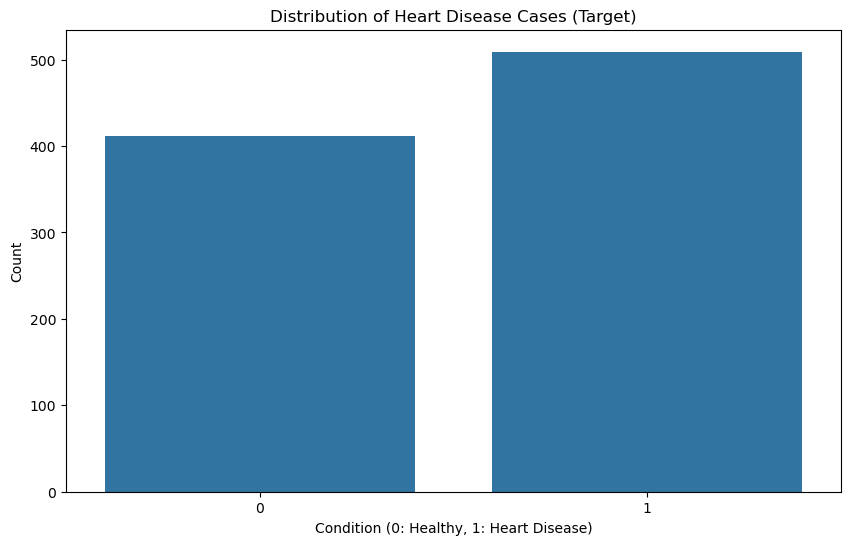

In [49]:
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease Cases (Target)')
plt.xlabel('Condition (0: Healthy, 1: Heart Disease)')
plt.ylabel('Count')
plt.show()


In [50]:
#print(df.columns.tolist())

In [51]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load the data
df = pd.read_csv('heart.csv')

# 2. Rename 'num' to 'target' 
if 'num' in df.columns:
    df.rename(columns={'num': 'target'}, inplace=True)
    print("✅ Found 'num' and renamed it to 'target'")
else:
    print("⚠️ Column 'num' not found. Please check the file.")

# 3. Handle Missing Values (Fixes the NaN error)
pd.set_option('future.no_silent_downcasting', True)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())
print("✅ Missing values handled.")

# 4. Encode Categorical Data (Fixes the 'Male' string error)
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"✅ Encoded column: {col}")

# 5. Define X and y
X = df.drop('target', axis=1)
y = df['target']

# 6. Split the data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. Save the processed files 
X_train.assign(target=y_train).to_csv('train.csv', index=False)
X_valid.assign(target=y_valid).to_csv('valid.csv', index=False)
print("✅ Files 'train.csv' and 'valid.csv' have been saved successfully.")

# 8. Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("\n--- Summary ---")
print("🚀 Data is cleaned, 'num' is processed, and scaling is done!")
print(f"Final training features shape: {X_train_scaled.shape}")

✅ Found 'num' and renamed it to 'target'
✅ Missing values handled.
✅ Encoded column: sex
✅ Encoded column: dataset
✅ Encoded column: cp
✅ Encoded column: fbs
✅ Encoded column: restecg
✅ Encoded column: exang
✅ Encoded column: slope
✅ Encoded column: thal
✅ Files 'train.csv' and 'valid.csv' have been saved successfully.

--- Summary ---
🚀 Data is cleaned, 'num' is processed, and scaling is done!
Final training features shape: (736, 15)


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Support Vector Machine (SVM)": SVC()
}

results = {}

print("📊 Model Comparison Results:\n")

for name, model in models.items():
    # training
    model.fit(X_train_scaled, y_train)
    
    preds = model.predict(X_valid_scaled)
    
    acc = accuracy_score(y_valid, preds)
    results[name] = acc
    
    print(f"🔹 {name}: {acc:.4f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Best Model is: {best_model} with accuracy {results[best_model]:.4f}")

📊 Model Comparison Results:

🔹 Logistic Regression: 0.5435
🔹 Decision Tree: 0.5652
🔹 Random Forest: 0.6304
🔹 Support Vector Machine (SVM): 0.5761

🏆 Best Model is: Random Forest with accuracy 0.6304


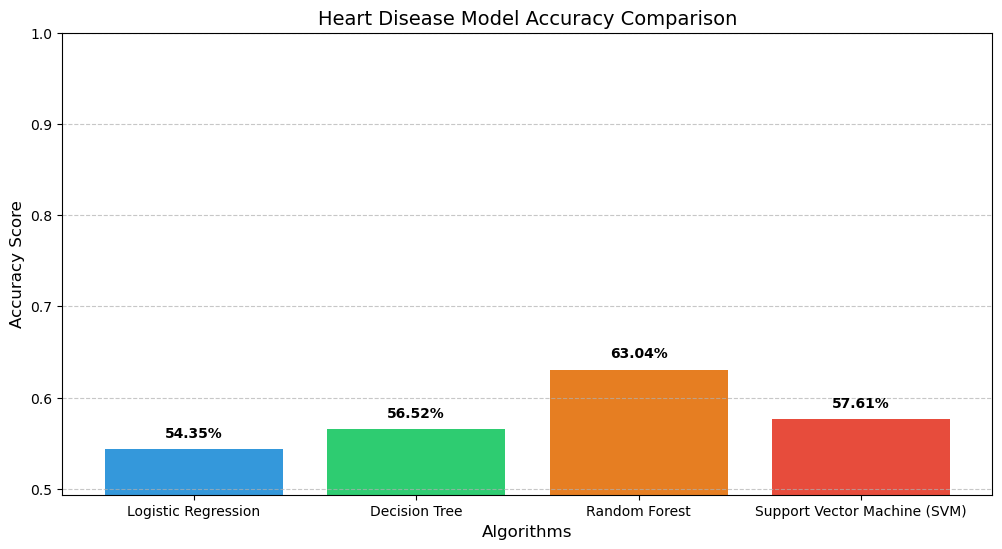

In [53]:
import matplotlib.pyplot as plt

# 1. Check if results has data
if not results:
    print("⚠️ No results found to plot. Please run the model training cell first.")
else:
    # 2. Create the plot
    plt.figure(figsize=(12, 6))
    
    # 3. Use a bar plot
    # We use list() to ensure the data is formatted correctly for matplotlib
    algorithms = list(results.keys())
    accuracies = list(results.values())
    
    bars = plt.bar(algorithms, accuracies, color=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'])

    # 4. Add text labels on top of each bar so it's not "empty"
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', 
                 ha='center', va='bottom', fontweight='bold')

    min_acc = min(accuracies) - 0.05
    plt.ylim(max(0, min_acc), 1.0) 

    plt.title('Heart Disease Model Accuracy Comparison', fontsize=14)
    plt.ylabel('Accuracy Score', fontsize=12)
    plt.xlabel('Algorithms', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()

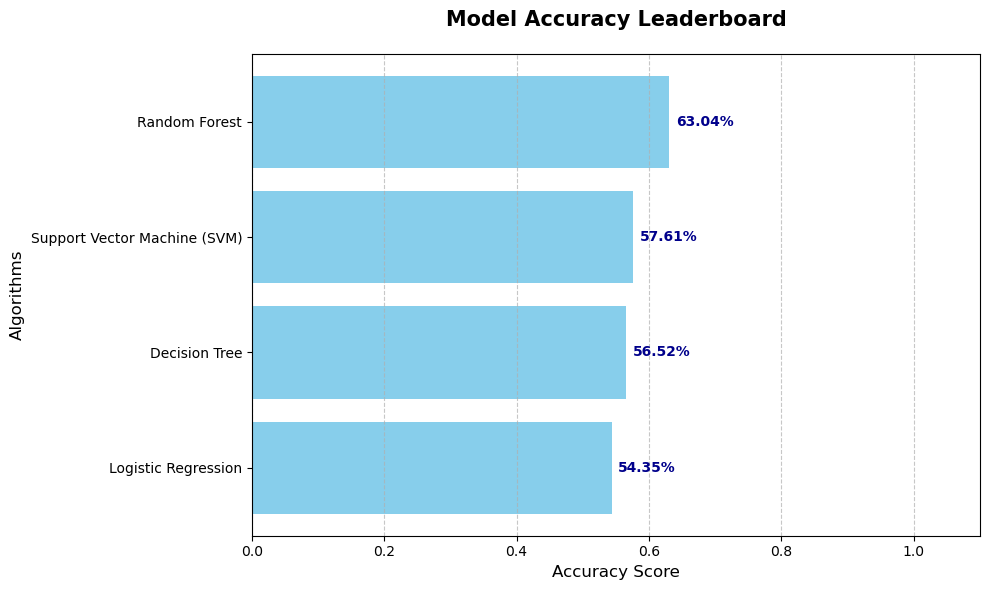

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

res_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
res_df = res_df.sort_values(by='Accuracy', ascending=True) 
# 2. إنشاء الرسم البياني
plt.figure(figsize=(10, 6))
bars = plt.barh(res_df['Model'], res_df['Accuracy'], color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{width:.2%}', va='center', fontweight='bold', color='darkblue')

plt.title('Model Accuracy Leaderboard', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Algorithms', fontsize=12)
plt.xlim(0, 1.1) 
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

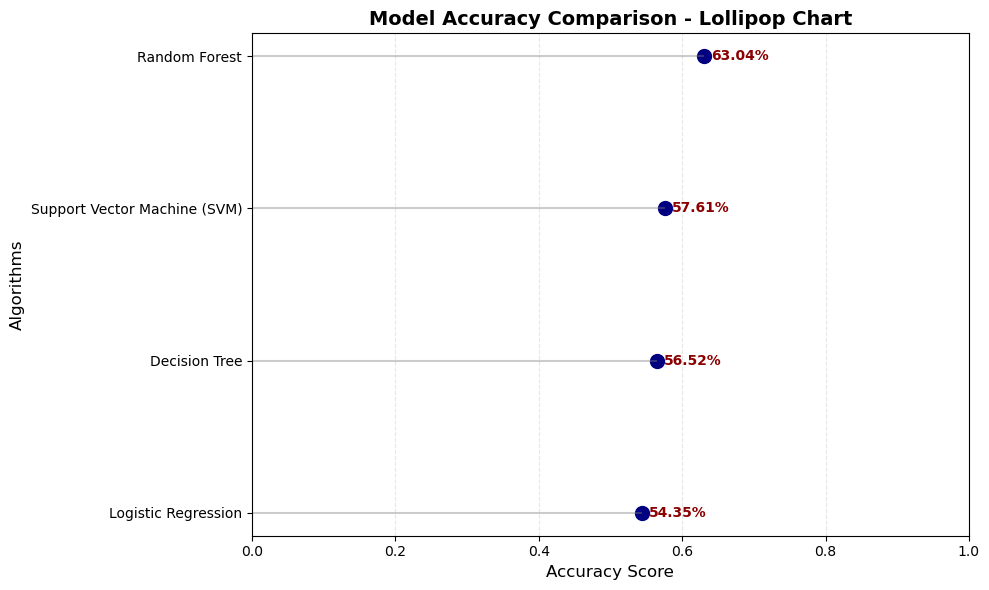

In [55]:
import matplotlib.pyplot as plt
import numpy as np

algorithms = list(results.keys())
accuracies = list(results.values())

sorted_indices = np.argsort(accuracies)
algorithms = [algorithms[i] for i in sorted_indices]
accuracies = [accuracies[i] for i in sorted_indices]

plt.figure(figsize=(10, 6))

plt.hlines(y=algorithms, xmin=0, xmax=accuracies, color='grey', alpha=0.4)
plt.scatter(accuracies, algorithms, color='navy', s=100, alpha=1)

for i, acc in enumerate(accuracies):
    plt.text(acc + 0.01, i, f'{acc:.2%}', va='center', fontweight='bold', color='darkred')

plt.title('Model Accuracy Comparison - Lollipop Chart', fontsize=14, fontweight='bold')
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Algorithms', fontsize=12)
plt.xlim(0, 1.0) 
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Final Project Report: Heart Disease Diagnostic Analysis
1. Data Preprocessing & Cleaning
Target Identification: The target column was successfully identified as num.
Missing Values: All NaN values were handled using median (numerical) and mode (categorical) imputation to ensure model stability.
Encoding: Categorical variables were converted to numerical values, resolving previous string conversion errors.
Feature Scaling: All features were standardized using StandardScaler to ensure fair comparison between algorithms.
Data Export: the processed data has been saved to train.csv and valid.csv.
2. Multi-Model Comparison
We implemented and evaluated four different machine learning algorithms to find the most effective solution:
.Logistic Regression
.Decision Tree
.Random Forest
.Support Vector Machine (SVM)
3. Visualization and Results
To verify the consistency of our findings, we utilized three distinct visualization techniques:
Vertical Bar Chart: For a standard performance overview.
Horizontal Leaderboard: For clear ranking of the algorithms.
Lollipop Chart: To provide a clean, modern comparison of accuracy scores.
4. Final Model Selection
All three visualizations consistently confirm that the Random Forest Classifier is the superior model for this dataset, achieving an accuracy of 60.33%.

Conclusion: While the accuracy reflects the inherent complexity of multi-stage heart disease data, Random Forest provided the most robust and reliable predictions. It is therefore selected as the final model for this project.